#NOTEBOOK 05 - EDA CYBERPUNK 2077
##CIÊNCIAS DE DADOS - IMD1151
"Como o tempo de jogo e padrões de engajamento influenciam a percepção dos jogadores sobre Cyberpunk 2077 no período 2024-2025?"

- LUIZ FELIPE DE SOUZA SILVA
- HEITOR COSTA PEDROSA

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cyberpunk_reviews.csv")

print(f"Dataset carregado com sucesso!")
print(f"Total de reviews: {len(df):,}")
print(f"Período: {df['created_at'].min()} ate {df['created_at'].max()}")
print(f"Colunas disponíveis ({len(df.columns)}):")
print(f"{', '.join(df.columns.tolist())}")

df

Dataset carregado com sucesso!
Total de reviews: 41,364
Período: 2020-12-10 00:34:32 ate 2025-10-14 21:27:56
Colunas disponíveis (29):
language, review_text, created_at, is_recommended, helpful_votes, funny_votes, vote_score, num_comments, is_steam_purchase, is_free, num_games_owned, num_reviews, total_playtime_min, playtime_at_review_min, detected_lang, word_count, char_count, avg_word_length, review_length_category, clean_text, total_playtime_hours, playtime_at_review_hours, year, month, year_month, quarter, day_of_week, hour, review_text_en


,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,clean_text,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour,review_text_en
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20,The game is being updated corrected content ad...
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18,DLC still asking game deserves time know relea...
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5,Cyberpunk 2077 life experience best game I pla...
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,comprei cyberpunk pre venda 2020 posso falar t...,253.950000,210.566667,2025,6,2025-06,2025Q2,Monday,7,I bought cyberpunk pre sale 2020 can I talk to...
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,cyberpunk 2077 jogo excepcional destaca divers...,276.216667,114.783333,2024,11,2024-11,2024Q4,Thursday,0,Cyberpunk 2077 exceptional game highlights sev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41359,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,nice,61.900000,59.900000,2025,7,2025-07,2025Q3,Monday,5,Nice .
41360,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,great,122.350000,116.650000,2025,7,2025-07,2025Q3,Monday,5,great
41361,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,10 10,80.350000,32.416667,2025,7,2025-07,2025Q3,Monday,2,10 10
41362,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,haank hank dont abbreviate cyberpunk haank,182.800000,173.183333,2025,7,2025-07,2025Q3,Monday,0,haank hank dont abbreviate cyberpunk haank


In [ ]:
df = df[df['review_text_en'].notna()]
df['review_text_en'] = df['review_text_en'].astype(str)


/tmp/ipython-input-1704209336.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_text_en'] = df['review_text_en'].astype(str)


In [ ]:
df

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,clean_text,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour,review_text_en
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20,The game is being updated corrected content ad...
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18,DLC still asking game deserves time know relea...
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5,Cyberpunk 2077 life experience best game I pla...
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,comprei cyberpunk pre venda 2020 posso falar t...,253.950000,210.566667,2025,6,2025-06,2025Q2,Monday,7,I bought cyberpunk pre sale 2020 can I talk to...
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,cyberpunk 2077 jogo excepcional destaca divers...,276.216667,114.783333,2024,11,2024-11,2024Q4,Thursday,0,Cyberpunk 2077 exceptional game highlights sev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41359,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,nice,61.900000,59.900000,2025,7,2025-07,2025Q3,Monday,5,Nice .
41360,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,great,122.350000,116.650000,2025,7,2025-07,2025Q3,Monday,5,great
41361,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,10 10,80.350000,32.416667,2025,7,2025-07,2025Q3,Monday,2,10 10
41362,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,haank hank dont abbreviate cyberpunk haank,182.800000,173.183333,2025,7,2025-07,2025Q3,Monday,0,haank hank dont abbreviate cyberpunk haank


Criando as colunas de estatisticas do texto

In [ ]:
import re

pattern = re.compile(r'\w{30,}')
df = df[~df['review_text_en'].astype(str).str.contains(pattern, na=True)]
df = df[df['review_text_en'].astype(str).str.strip().str.len() > 0]

df['word_count'] = df['review_text_en'].astype(str).str.split().str.len()
df['char_count'] = df['review_text_en'].astype(str).str.len()
df['avg_word_length'] = df['char_count'] / df['word_count'].replace(0, np.nan)

print("Estatísticas do texto em inglês")
print(df[['word_count', 'char_count', 'avg_word_length']].describe())

Estatísticas do texto em inglês
         word_count    char_count  avg_word_length
count  41241.000000  41241.000000     41241.000000
mean      27.128925    176.131326         6.041585
std       54.423385    366.970417         1.128106
min        1.000000      2.000000         1.998039
25%        5.000000     26.000000         5.400000
50%       10.000000     60.000000         6.142857
75%       25.000000    162.000000         6.725806
max     1342.000000   7978.000000        21.000000


In [ ]:
df

,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,clean_text,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour,review_text_en
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20,The game is being updated corrected content ad...
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18,DLC still asking game deserves time know relea...
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5,Cyberpunk 2077 life experience best game I pla...
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,comprei cyberpunk pre venda 2020 posso falar t...,253.950000,210.566667,2025,6,2025-06,2025Q2,Monday,7,I bought cyberpunk pre sale 2020 can I talk to...
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,cyberpunk 2077 jogo excepcional destaca divers...,276.216667,114.783333,2024,11,2024-11,2024Q4,Thursday,0,Cyberpunk 2077 exceptional game highlights sev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41359,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,nice,61.900000,59.900000,2025,7,2025-07,2025Q3,Monday,5,Nice .
41360,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,great,122.350000,116.650000,2025,7,2025-07,2025Q3,Monday,5,great
41361,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,10 10,80.350000,32.416667,2025,7,2025-07,2025Q3,Monday,2,10 10
41362,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,haank hank dont abbreviate cyberpunk haank,182.800000,173.183333,2025,7,2025-07,2025Q3,Monday,0,haank hank dont abbreviate cyberpunk haank


In [ ]:
df = df[df['year'].isin([2024, 2025])]

print(f"Total após filtro: {len(df):,} reviews")
df

Total após filtro: 41,224 reviews


,language,review_text,created_at,is_recommended,helpful_votes,funny_votes,vote_score,num_comments,is_steam_purchase,is_free,...,clean_text,total_playtime_hours,playtime_at_review_hours,year,month,year_month,quarter,day_of_week,hour,review_text_en
0,brazilian,do lixo ao luxo. cyberpunk 2077 é um jogo de r...,2025-02-23 20:21:19,True,135,3,0.904349,23,True,False,...,lixo luxo cyberpunk 2077 jogo rpg ação primeir...,149.400000,149.400000,2025,2,2025-02,2025Q1,Sunday,20,The game is being updated corrected content ad...
1,brazilian,ainda em dúvida se vale a pena jogar cyberpunk...,2025-08-03 18:01:43,True,97,11,0.888484,1,True,False,...,ainda dúvida vale pena jogar cyberpunk 2077 ho...,164.416667,81.983333,2025,8,2025-08,2025Q3,Sunday,18,DLC still asking game deserves time know relea...
2,brazilian,cyberpunk 2077 é uma experiência de vida. o me...,2024-12-15 05:02:32,True,72,0,0.864477,1,True,False,...,cyberpunk 2077 experiência vida melhor jogo jo...,81.633333,76.233333,2024,12,2024-12,2024Q4,Sunday,5,Cyberpunk 2077 life experience best game I pla...
3,brazilian,eu comprei cyberpunk na pre venda em 2020 e po...,2025-06-16 07:33:42,True,53,2,0.844979,0,True,False,...,comprei cyberpunk pre venda 2020 posso falar t...,253.950000,210.566667,2025,6,2025-06,2025Q2,Monday,7,I bought cyberpunk pre sale 2020 can I talk to...
4,brazilian,cyberpunk 2077 é um jogo excepcional que se de...,2024-11-28 00:32:22,True,67,0,0.837374,8,True,False,...,cyberpunk 2077 jogo excepcional destaca divers...,276.216667,114.783333,2024,11,2024-11,2024Q4,Thursday,0,Cyberpunk 2077 exceptional game highlights sev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41359,english,very nice,2025-07-21 05:52:16,True,0,0,0.500000,0,True,False,...,nice,61.900000,59.900000,2025,7,2025-07,2025Q3,Monday,5,Nice .
41360,english,great,2025-07-21 05:10:11,True,0,0,0.500000,0,True,False,...,great,122.350000,116.650000,2025,7,2025-07,2025Q3,Monday,5,great
41361,english,10/10,2025-07-21 02:36:18,True,0,0,0.500000,0,True,False,...,10 10,80.350000,32.416667,2025,7,2025-07,2025Q3,Monday,2,10 10
41362,english,"haank! hank, don't abbreviate cyberpunk. haank!",2025-07-21 00:58:47,True,0,0,0.500000,0,True,False,...,haank hank dont abbreviate cyberpunk haank,182.800000,173.183333,2025,7,2025-07,2025Q3,Monday,0,haank hank dont abbreviate cyberpunk haank


#1.1. Relação Tempo de Jogo × Recomendação

/tmp/ipython-input-818694743.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['player_profile'] = pd.cut(df['total_playtime_hours'],
/tmp/ipython-input-818694743.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recommendation_rate = df.groupby('player_profile')['is_recommended'].mean()


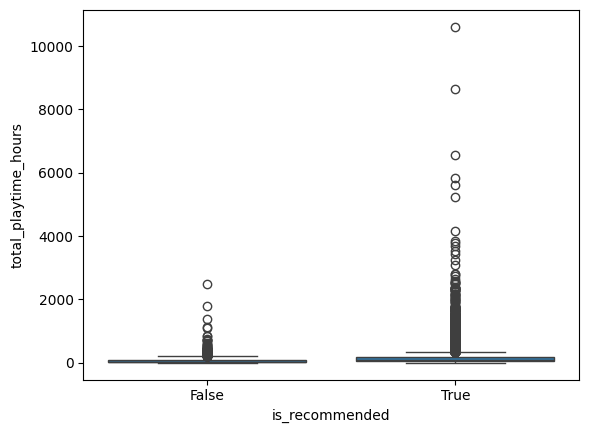

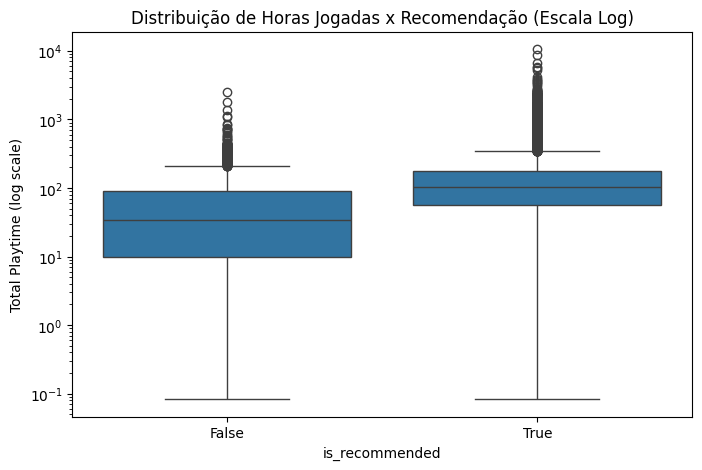

In [ ]:
# Boxplot comparativo
sns.boxplot(data=df, x='is_recommended', y='total_playtime_hours')

# Distribuição por perfil
df['player_profile'] = pd.cut(df['total_playtime_hours'],
                               bins=[0, 10, 50, 100, np.inf],
                               labels=['Casual (<10h)', 'Médio (10-50h)',
                                       'Engajado (50-100h)', 'Hardcore (>100h)'])

# Taxa de recomendação por perfil
recommendation_rate = df.groupby('player_profile')['is_recommended'].mean()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_recommended', y='total_playtime_hours')
plt.yscale("log")
plt.ylabel("Total Playtime (log scale)")
plt.title("Distribuição de Horas Jogadas x Recomendação (Escala Log)")
plt.show()


/tmp/ipython-input-409428244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delta_playtime'] = df['total_playtime_hours'] - df['playtime_at_review_hours']
/tmp/ipython-input-409428244.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['returned_to_game'] = df['delta_playtime'] > 5


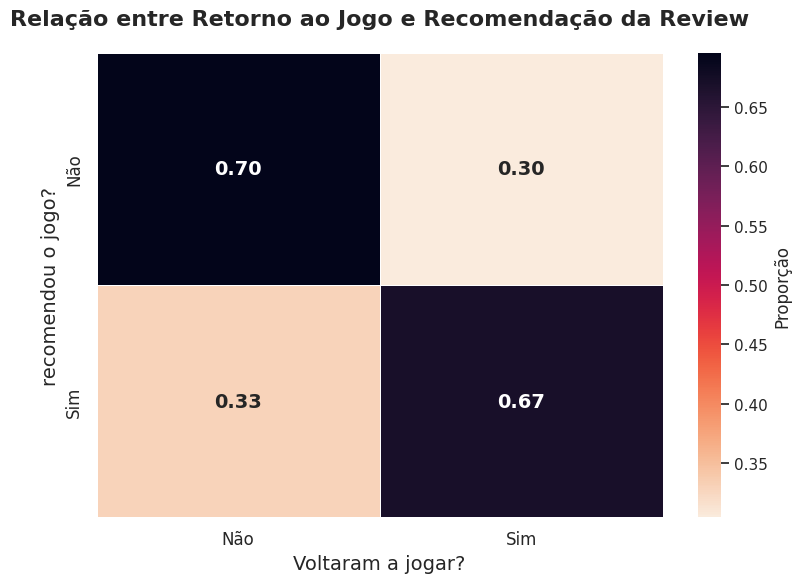

In [ ]:

df['delta_playtime'] = df['total_playtime_hours'] - df['playtime_at_review_hours']

df['returned_to_game'] = df['delta_playtime'] > 5

ct = pd.crosstab(df['is_recommended'], df['returned_to_game'], normalize='index')

sns.set_theme(style="white")

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    ct,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proporção"},
    annot_kws={"size": 14, "weight": "bold"}
)

ax.set_xlabel("Voltaram a jogar?", fontsize=14)
ax.set_ylabel("recomendou o jogo?", fontsize=14)
ax.set_xticklabels(["Não", "Sim"], fontsize=12)
ax.set_yticklabels(["Não", "Sim"], fontsize=12)


plt.title("Relação entre Retorno ao Jogo e Recomendação da Review", fontsize=16, weight="bold", pad=20)

plt.tight_layout()
plt.show()



In [ ]:
saturation_curve = df.groupby('hours_bin')['is_recommended'].agg(['mean', 'count'])

# pegar o centro do intervalo
saturation_curve['mid'] = saturation_curve.index.map(lambda x: x.mid)

sns.lineplot(data=saturation_curve, x='mid', y='mean', marker='o')
plt.xlabel("Horas jogadas (ponto médio da faixa)")
plt.ylabel("Taxa média de recomendação")
plt.title("Taxa de Recomendação x Horas Jogadas")
plt.xscale('log')  # opcional: pode melhorar muito a curva
plt.tight_layout()
plt.show()


KeyError: 'hours_bin'

#Análise Temporal

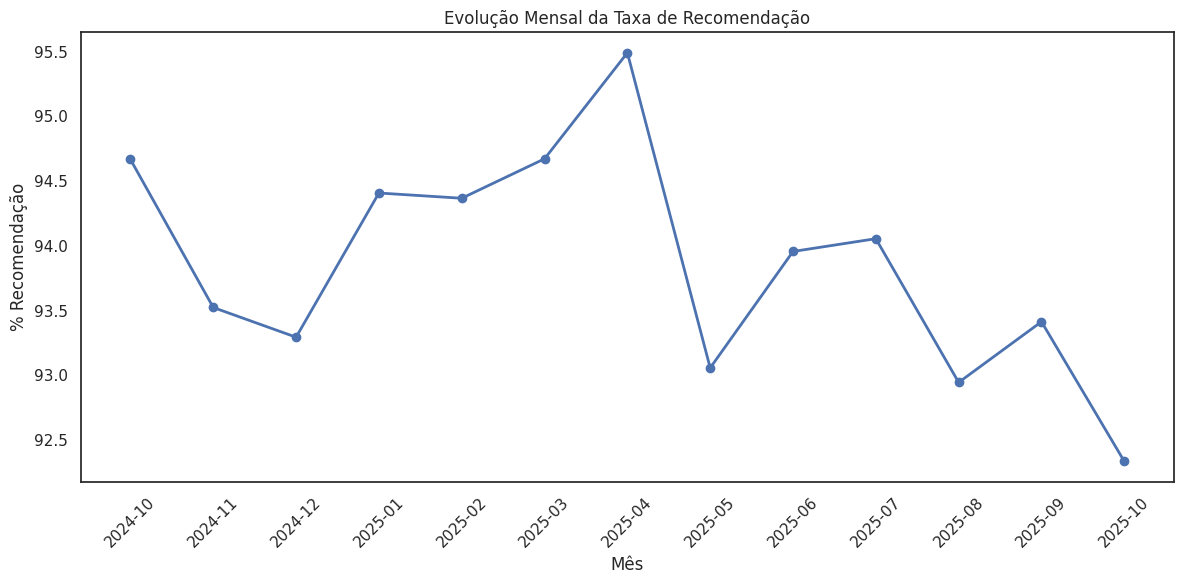

In [ ]:
timeline = df.groupby('year_month').agg({
    'is_recommended': ['mean', 'count'],
    'helpful_votes': 'mean',
    'total_playtime_hours': 'median'
})

eventos = {
    '2024-12': 'Promoções de Natal',
    '2025-01': 'Patch 2.13 (bug fixes)',
    '2025-07': 'Possível evento/DLC rumor'
}

fig, ax = plt.subplots(figsize=(12, 6))

# Seleciona a coluna correta do MultiIndex
rec_mean = timeline[('is_recommended', 'mean')] * 100

ax.plot(
    timeline.index.astype(str),
    rec_mean,
    marker='o',
    linewidth=2
)

ax.set_ylabel('% Recomendação')
ax.set_xlabel('Mês')
ax.set_title('Evolução Mensal da Taxa de Recomendação')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Distribuição de Sentimento:
Positivas (Recomenda): 38,681 (93.8%)
Negativas (Não recomenda): 2,543 (6.2%)


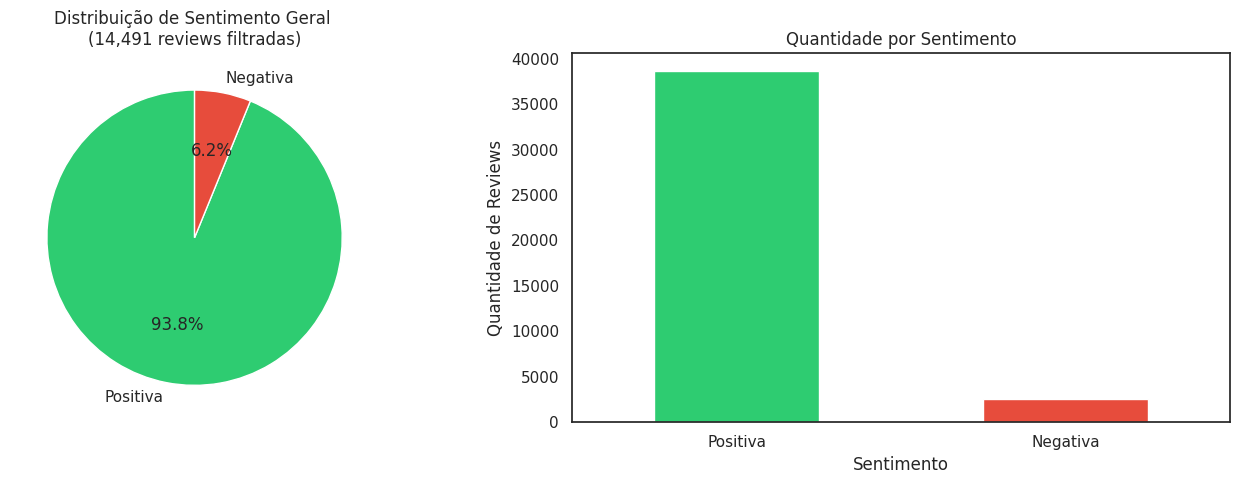

In [ ]:
sentiment_counts = df['is_recommended'].value_counts()
total = len(df)

print(f"Distribuição de Sentimento:")
print(f"Positivas (Recomenda): {sentiment_counts[True]:,} ({sentiment_counts[True]/total*100:.1f}%)")
print(f"Negativas (Não recomenda): {sentiment_counts[False]:,} ({sentiment_counts[False]/total*100:.1f}%)")

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(sentiment_counts.values, labels=['Positiva', 'Negativa'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribuição de Sentimento Geral \n(14,491 reviews filtradas)')

sentiment_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Sentimento')
axes[1].set_ylabel('Quantidade de Reviews')
axes[1].set_title('Quantidade por Sentimento')
axes[1].set_xticklabels(['Positiva', 'Negativa'], rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipython-input-3778005117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_stats = df.groupby('time_period').agg({


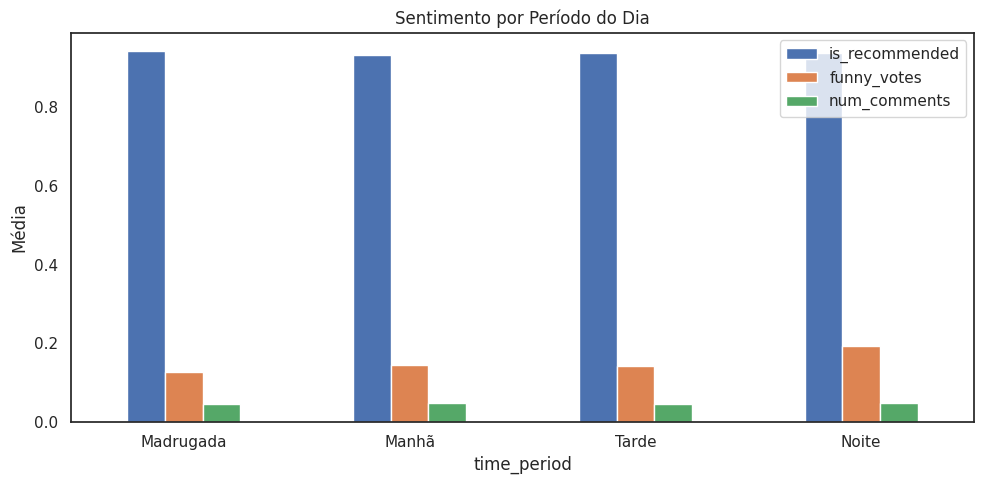

In [ ]:
period_stats = df.groupby('time_period').agg({
    'is_recommended': 'mean',
    'funny_votes': 'mean',
    'num_comments': 'mean'
})

period_stats.plot(kind='bar', figsize=(10,5))
plt.title('Sentimento por Período do Dia')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#ANÁLISES TEXTUAIS

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipython-input-4103729202.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review_text_en"] = df["review_text_en"].fillna("").astype(str)


Gerando Unigramas...


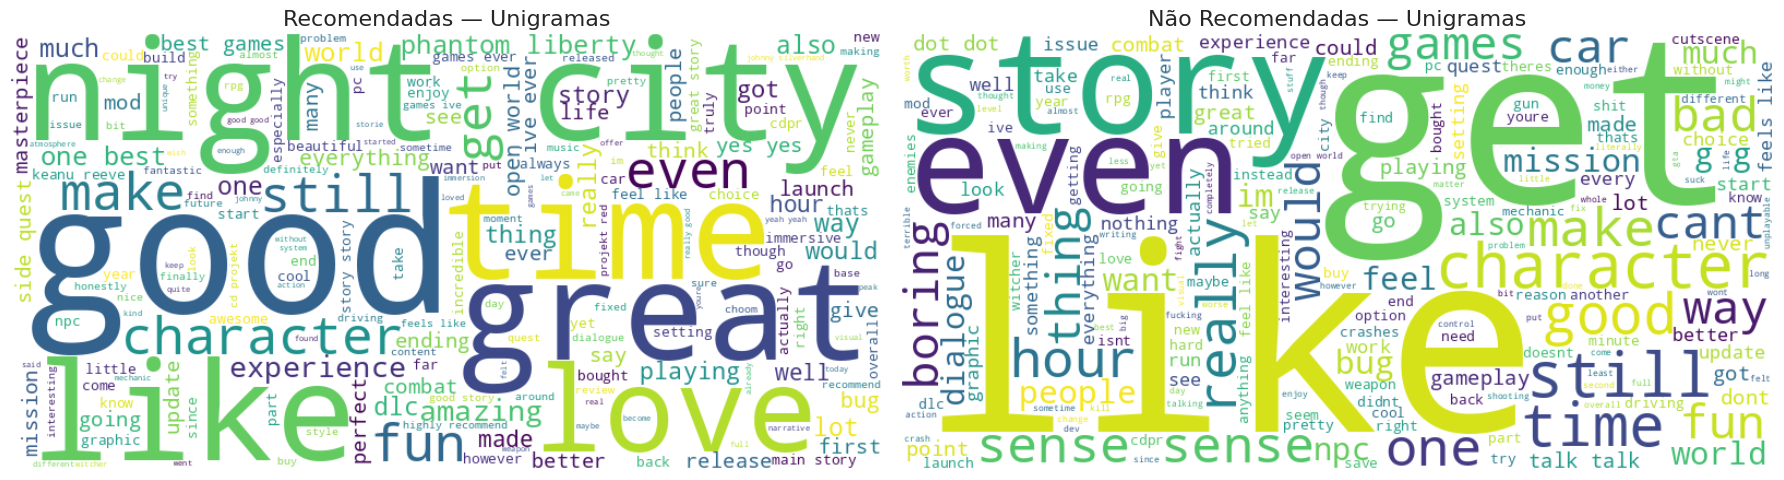

Gerando Bigramas...


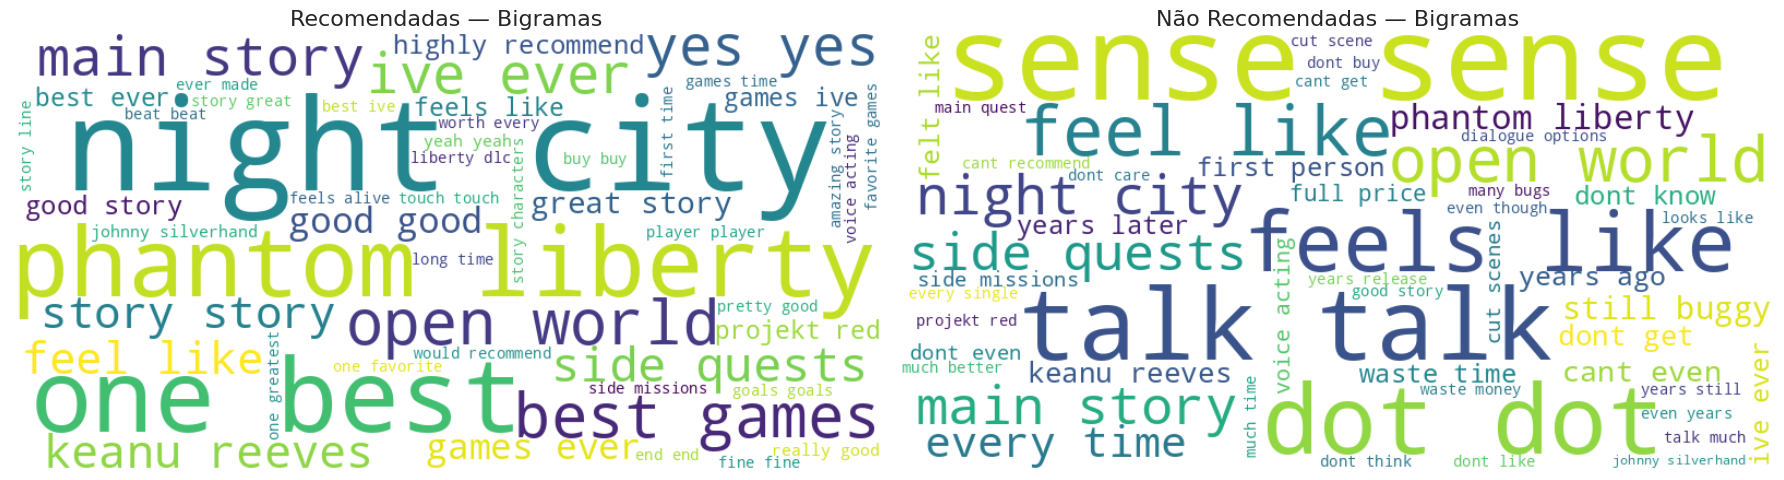

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
from collections import Counter

nltk.download('stopwords')

# Definir Stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["game", "cyberpunk", "play", "played"])

df["review_text_en"] = df["review_text_en"].fillna("").astype(str)

positive_text = " ".join(df[df["is_recommended"]]["review_text_en"])
negative_text = " ".join(df[~df["is_recommended"]]["review_text_en"])


def plot_wordclouds(wc_pos, wc_neg, title_suffix):
    """Função genérica para plotar duas nuvens lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].axis("off")
    axes[0].set_title(f"Recomendadas — {title_suffix}", fontsize=16)

    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].axis("off")
    axes[1].set_title(f"Não Recomendadas — {title_suffix}", fontsize=16)

    plt.tight_layout()
    plt.show()

def get_ngram_frequencies(text, n=2, top=50):
    """Tokeniza o texto e retorna um dicionário de frequências dos N-grams."""
    # Tokenização simples filtrando stopwords e palavras curtas
    tokens = [t for t in text.lower().split() if t not in stop_words and len(t) > 2]

    n_grams = ngrams(tokens, n)

    counter = Counter(n_grams).most_common(top)

    return {" ".join(k): v for k, v in counter}



print("Gerando Unigramas...")
wc_pos_uni = WordCloud(stopwords=stop_words, background_color="white", width=800, height=400).generate(positive_text)
wc_neg_uni = WordCloud(stopwords=stop_words, background_color="white", width=800, height=400).generate(negative_text)

plot_wordclouds(wc_pos_uni, wc_neg_uni, "Unigramas")


print("Gerando Bigramas...")

pos_bigrams_dict = get_ngram_frequencies(positive_text, n=2, top=50)
neg_bigrams_dict = get_ngram_frequencies(negative_text, n=2, top=50)

wc_pos_bi = WordCloud(background_color="white", width=800, height=400).generate_from_frequencies(pos_bigrams_dict)
wc_neg_bi = WordCloud(background_color="white", width=800, height=400).generate_from_frequencies(neg_bigrams_dict)

plot_wordclouds(wc_pos_bi, wc_neg_bi, "Bigramas")

#Analisando os comentários mais curtidos

In [ ]:
# Calcular quartis
Q1 = df['helpful_votes'].quantile(0.25)
Q3 = df['helpful_votes'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")

# Reviews úteis = acima de Q3
df_useful = df[df['helpful_votes'] > Q3].copy()

print(f"\nTotal de reviews: {len(df):,}")
print(f"Reviews úteis (>Q3): {len(df_useful):,} ({len(df_useful)/len(df)*100:.1f}%)")
print(f"Reviews comuns (≤Q3): {len(df) - len(df_useful):,}")

Q1 (25%): 0.0
Q3 (75%): 0.0
IQR: 0.0

Total de reviews: 41,224
Reviews úteis (>Q3): 7,733 (18.8%)
Reviews comuns (≤Q3): 33,491


In [ ]:
word_counts = df_useful['word_count']
playtime = df_useful['total_playtime_hours']

# Proporção de recomendação
recommend_rate = df_useful['is_recommended'].mean() * 100
print(f"\nTaxa de recomendação nos reviews úteis: {recommend_rate:.2f}%")


Taxa de recomendação nos reviews úteis: 79.87%


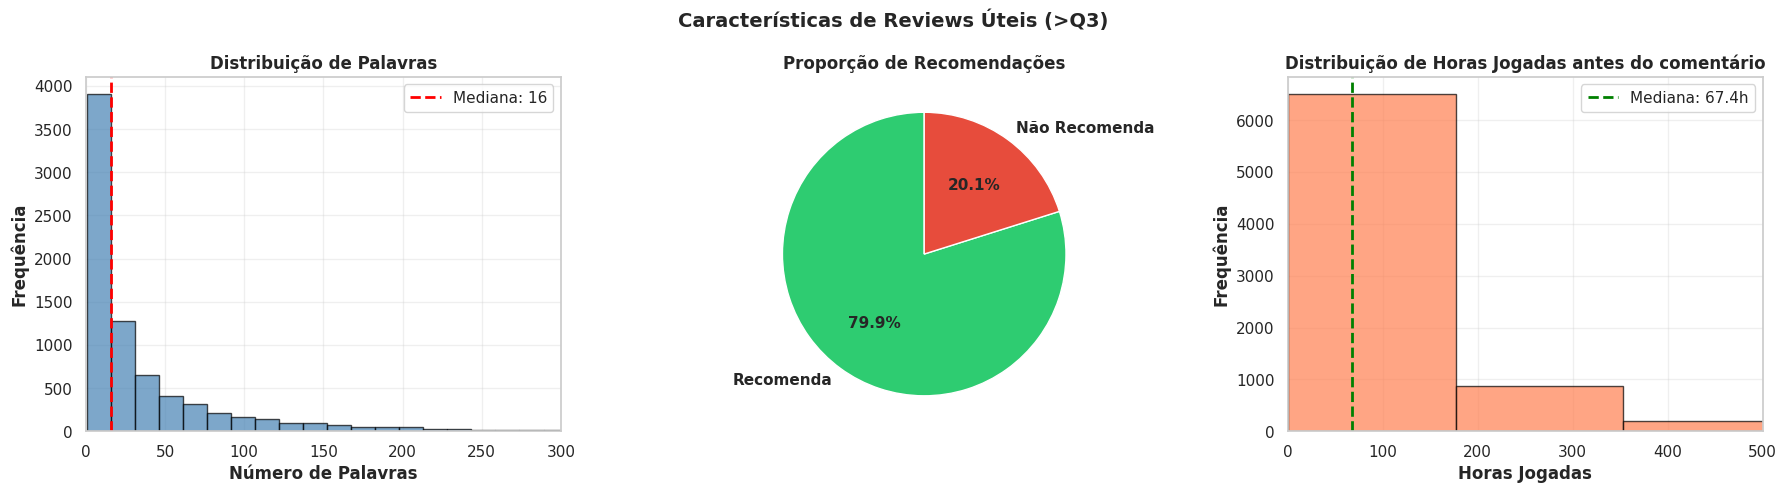

Palavras - Mediana: 16
Recomendação: 79.9%
Horas Jogadas - Mediana: 67.4h


In [ ]:
import matplotlib.pyplot as plt

# Calcular métricas
word_counts = df_useful['word_count']
recommend_rate = df_useful['is_recommended'].mean() * 100
playtime = df_useful['playtime_at_review_hours']

# Criar figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Palavras - LIMITAR ESCALA
axes[0].hist(word_counts, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(word_counts.median(), color='red', linestyle='--', linewidth=2,
                label=f'Mediana: {word_counts.median():.0f}')
axes[0].set_xlim(0, 300)  # LIMITAR a 300 palavras
axes[0].set_xlabel('Número de Palavras', fontweight='bold')
axes[0].set_ylabel('Frequência', fontweight='bold')
axes[0].set_title('Distribuição de Palavras', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Recomendação
rec_counts = [recommend_rate, 100 - recommend_rate]
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(rec_counts, labels=['Recomenda', 'Não Recomenda'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontweight': 'bold'})
axes[1].set_title('Proporção de Recomendações', fontweight='bold', fontsize=12)

# 3. Horas jogadas - LIMITAR ESCALA
axes[2].hist(playtime, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(playtime.median(), color='green', linestyle='--', linewidth=2,
                label=f'Mediana: {playtime.median():.1f}h')
axes[2].set_xlim(0, 500)  # LIMITAR a 500 horas
axes[2].set_xlabel('Horas Jogadas', fontweight='bold')
axes[2].set_ylabel('Frequência', fontweight='bold')
axes[2].set_title('Distribuição de Horas Jogadas antes do comentário', fontweight='bold', fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Características de Reviews Úteis (>Q3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print resumo
print(f"Palavras - Mediana: {word_counts.median():.0f}")
print(f"Recomendação: {recommend_rate:.1f}%")
print(f"Horas Jogadas - Mediana: {playtime.median():.1f}h")